## Imports

In [ ]:
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
import re

# Add qudi-iqo-modules to path so we can use spc.py directly (no running Qudi needed)
QUDI_MODULES = Path(r'C:\Users\SPUD1\Documents\experiment_workspace\qudi-iqo-modules\src')
if str(QUDI_MODULES) not in sys.path:
    sys.path.insert(0, str(QUDI_MODULES))

from qudi.hardware.camera.SPC3.spc_old import SPC3

plt.rcParams['figure.figsize'] = (12, 4)


In [8]:
spad_dir = r'C:\Users\SPUD1\Documents\experiment_workspace\SPAD data'
spad_file_header = 'frame_ugh_ugh' #'test_ODMR'
qm_dir    = r'C:\Users\SPUD1\Documents\experiment_workspace\qua-libs\Quantum-Control-Applications\Optically addressable spin qubits\NV2_array_SPAD\Data\2026-03-06\#23_pulsed_odmr_133141'


## Load metadata from QM DataHandler output (data.json / arrays.npz)

In [9]:
def _resolve_npz_ref(ref_str, base_dir):
    """Resolve a DataHandler array reference like './arrays.npz#IF_frequencies'."""
    if isinstance(ref_str, str) and '#' in ref_str:
        file_part, key = ref_str.split('#', 1)
        npz_path = (Path(base_dir) / file_part).resolve()
        return np.load(npz_path)[key]
    return ref_str

qm_dir = Path(qm_dir)
with open(qm_dir / 'data.json', 'r') as f:
    meta = json.load(f)

# Resolve IF_frequencies (may be an npz reference)
if_raw = meta.get('IF_frequencies')
f_vec = np.asarray(_resolve_npz_ref(if_raw, qm_dir), dtype=float)

n_avg = int(meta.get('n_avg', 1))
# 'iteration' is 0-indexed: value 0 → 1 completed, 99999 → 100000 completed
# Falls back to n_avg when the field is absent (n_avg - 1 + 1 = n_avg)
n_iteration = int(meta.get('iteration', n_avg - 1)) + 1

print(f"n_avg        : {n_avg}  (requested)")
print(f"n_iteration  : {n_iteration}  (actually completed)")
if n_iteration != n_avg:
    print(f"  ↳ experiment was interrupted at {n_iteration / n_avg * 100:.1f}% of target")
print(f"len(f_vec)   : {len(f_vec)}")
print(f"f_vec range  : {f_vec.min()/1e6:.1f} – {f_vec.max()/1e6:.1f} MHz")
print(f"Expected total frames: {2 * n_iteration * len(f_vec)}")


n_avg        : 100000  (requested)
n_iteration  : 100000  (actually completed)
len(f_vec)   : 80
f_vec range  : 60.0 – 99.5 MHz
Expected total frames: 16000000


## Load SPC3 files — streaming accumulation with background subtraction

Files are processed one at a time in their native `uint8`/`uint16` dtype.  Each file's frames are
immediately demuxed into signal and reference `float64` accumulators of shape `(F, rows, cols)`, then
discarded.  Peak RAM usage is one file at a time plus two small accumulators — independent of total
recording length.  A carry buffer handles rep boundaries that fall mid-file.

If a background sidecar `<header>.bg.npy` is found next to the `.spc3` files (saved automatically
by qudi when background subtraction is enabled at acquisition time), it is subtracted from every
frame **before** accumulation, with the result clamped to zero.  This ensures the ODMR contrast is
computed on background-free counts.


In [10]:

spad_dir_path = Path(spad_dir)

# -----------------------------------------------------------------
# Discover all part-files matching <header>.spc3, <header>2.spc3, ...
# Only digits (never other text) may follow the header — this prevents
# "ODMR_test_new.spc3" being picked up when header is "ODMR_test".
# -----------------------------------------------------------------
def _spc3_sort_key(p):
    m = re.search(r'(\d+)\.spc3$', p.name, re.IGNORECASE)
    return int(m.group(1)) if m else 0

_part_re = re.compile(
    r'^' + re.escape(spad_file_header) + r'\d*\.spc3$',
    re.IGNORECASE
)

spc3_files = sorted(
    (p for p in spad_dir_path.glob(f'{spad_file_header}*.spc3') if _part_re.match(p.name)),
    key=_spc3_sort_key
)

if not spc3_files:
    raise FileNotFoundError(
        f"No SPC3 files found matching '{spad_file_header}[<digits>].spc3' in\n  {spad_dir_path}"
    )

print(f"Found {len(spc3_files)} SPC3 file(s):")
for fp in spc3_files:
    print(f"  {fp.name}")

# -----------------------------------------------------------------
# Load background sidecar (.bg.npy) if present alongside the .spc3 files.
#
# The sidecar is saved automatically by qudi at the end of each acquisition
# IF a background image was captured beforehand.  Required workflow in qudi:
#   1. Click "Capture Background"  (before starting acquisition)
#   2. Toggle "Background Subtraction" ON
#   3. Start acquisition
# If no sidecar is found, check the qudi log for a warning message.
#
# Shape: float32 (rows, cols)
# -----------------------------------------------------------------
bg_sidecar = spad_dir_path / (spad_file_header + '.bg.npy')
if bg_sidecar.exists():
    background = np.load(bg_sidecar).astype(np.float64)   # (rows, cols)
    print(f"\nBackground sidecar loaded: {bg_sidecar.name}  shape={background.shape}")
else:
    background = None
    print(f"\nNo background sidecar found ({bg_sidecar.name}) — skipping subtraction.")
    print("  To enable: in qudi, click 'Capture Background' THEN toggle 'Background Subtraction' ON before acquisition.")

# -----------------------------------------------------------------
# Streaming accumulation
#
# Frame ordering (per repetition):
#   sig_f0, ref_f0, sig_f1, ref_f1, ..., sig_f{F-1}, ref_f{F-1}
# Total frames per rep = 2 * F.
#
# For each file:
#  - Load frames in native dtype (uint8 / uint16) — minimal RAM
#  - Cast to float64 only for the per-file batch sum (small result)
#  - Subtract background (if loaded) pixel-by-pixel, clamp to ≥ 0
#  - Accumulate into float64 sig_sum / ref_sum of shape (F, rows, cols)
#
# This avoids integer overflow for any pixel dtype or rep count, while
# never holding the full frame stack in memory.
# -----------------------------------------------------------------
F              = len(f_vec)
frames_per_rep = 2 * F

header          = None
sig_sum         = None   # (F, rows, cols) float64
ref_sum         = None   # (F, rows, cols) float64
n_complete_reps = 0
n_rows = n_cols = None
carry           = None   # leftover frames from the previous file (< frames_per_rep)
N_frames_raw    = 0      # total frames across all files (before truncation)

for fp in spc3_files:
    f_data, h = SPC3.ReadSPC3DataFile(str(fp))
    frames = f_data[0]          # (N, rows, cols) — native uint8 or uint16
    N_frames_raw += frames.shape[0]

    if header is None:
        header = h
        n_rows, n_cols = frames.shape[1], frames.shape[2]
        print(f"\nRaw frame dtype      : {frames.dtype}")
        sig_sum = np.zeros((F, n_rows, n_cols), dtype=np.float64)
        ref_sum = np.zeros((F, n_rows, n_cols), dtype=np.float64)

        # Validate background dimensions
        if background is not None and background.shape != (n_rows, n_cols):
            print(f"WARNING: background shape {background.shape} != frame shape "
                  f"({n_rows}, {n_cols}) — disabling background subtraction")
            background = None

    # Prepend any incomplete rep left over from the previous file
    if carry is not None:
        frames = np.concatenate([carry, frames], axis=0)
        carry = None

    n_frames        = frames.shape[0]
    n_complete_here = (n_frames // frames_per_rep) * frames_per_rep

    if n_complete_here > 0:
        # Cast to float64 here (per-file batch) before summing — avoids integer
        # overflow regardless of native pixel dtype (uint8 max 255, uint16 max 65535)
        batch = frames[:n_complete_here].astype(np.float64)

        # Background subtraction: subtract and clamp to zero
        if background is not None:
            batch = np.maximum(batch - background[np.newaxis, :, :], 0.0)

        rep_view = batch.reshape(-1, F, 2, n_rows, n_cols)
        sig_sum += rep_view[:, :, 0, :, :].sum(axis=0)
        ref_sum += rep_view[:, :, 1, :, :].sum(axis=0)
        n_complete_reps += n_complete_here // frames_per_rep

    if n_frames > n_complete_here:
        carry = frames[n_complete_here:]    # save incomplete rep for next file

    print(f"  {fp.name}: {n_complete_here} frames used  "
          f"(running total: {n_complete_reps} complete reps)")

dropped = N_frames_raw - n_complete_reps * frames_per_rep
print(f"\nTotal frames raw     : {N_frames_raw}")
print(f"Complete repetitions : {n_complete_reps}  ({n_complete_reps / n_iteration * 100:.1f}% of {n_iteration} completed, {n_avg} requested)")
if dropped:
    print(f"Dropped trailing     : {dropped} frame(s) (incomplete final repetition)")
print(f"Background subtracted: {'yes' if background is not None else 'no'}")
print(f"Accumulator dtype    : {sig_sum.dtype}  shape: {sig_sum.shape}")
print(f"HwIntTime            : {header.HwIntTime*1e9:.1f} ns  ({header.SummedFrames} summed frames in hw)")

gate_on       = header.CoarseGate_C1_ON
gate_start_ns = header.CoarseGate_C1_startPos * 1e9
gate_stop_ns  = header.CoarseGate_C1_stopPos  * 1e9
if gate_on:
    print(f"CoarseGate C1        : ON  start={gate_start_ns:.0f} ns  stop={gate_stop_ns:.0f} ns")
else:
    print(f"CoarseGate C1        : OFF")


Found 16 SPC3 file(s):
  frame_ugh_ugh.spc3
  frame_ugh_ugh2.spc3
  frame_ugh_ugh3.spc3
  frame_ugh_ugh4.spc3
  frame_ugh_ugh5.spc3
  frame_ugh_ugh6.spc3
  frame_ugh_ugh7.spc3
  frame_ugh_ugh8.spc3
  frame_ugh_ugh9.spc3
  frame_ugh_ugh10.spc3
  frame_ugh_ugh11.spc3
  frame_ugh_ugh12.spc3
  frame_ugh_ugh13.spc3
  frame_ugh_ugh14.spc3
  frame_ugh_ugh15.spc3
  frame_ugh_ugh16.spc3

No background sidecar found (frame_ugh_ugh.bg.npy) — skipping subtraction.
  To enable: in qudi, click 'Capture Background' THEN toggle 'Background Subtraction' ON before acquisition.

Raw frame dtype      : uint8
  frame_ugh_ugh.spc3: 1048480 frames used  (running total: 6553 complete reps)
  frame_ugh_ugh2.spc3: 1048640 frames used  (running total: 13107 complete reps)
  frame_ugh_ugh3.spc3: 1048480 frames used  (running total: 19660 complete reps)
  frame_ugh_ugh4.spc3: 1048640 frames used  (running total: 26214 complete reps)
  frame_ugh_ugh5.spc3: 1048480 frames used  (running total: 32767 complete reps)
 

## Compute per-frequency averages from accumulators

Signal and reference counts were accumulated as `uint32` during loading.
Dividing by `n_complete_reps` here produces `float64` averages — the conversion
happens once on the small `(F, rows, cols)` arrays, not on the full frame stack.


In [11]:
if n_complete_reps == 0:
    raise RuntimeError("No complete repetitions found — check spad_file_header and f_vec length.")

# Convert uint32 accumulators to float64 averages (small arrays: F × rows × cols)
sig_avg  = sig_sum / n_complete_reps   # (F, rows, cols) float64
ref_avg  = ref_sum / n_complete_reps   # (F, rows, cols) float64
diff_avg = sig_avg - ref_avg           # (F, rows, cols) float64

print(f"n_complete_reps  : {n_complete_reps}  ({n_complete_reps / n_iteration * 100:.1f}% of {n_iteration} completed, {n_avg} requested)")
print(f"sig_avg shape    : {sig_avg.shape}  dtype: {sig_avg.dtype}")
print(f"Mean counts/px   : sig={sig_avg.mean():.4f}  ref={ref_avg.mean():.4f}")


n_complete_reps  : 99999  (100.0% of 100000 completed, 100000 requested)
sig_avg shape    : (80, 32, 32)  dtype: float64
Mean counts/px   : sig=0.0016  ref=0.0016


## Plot averaged images at each frequency (signal / reference / difference)

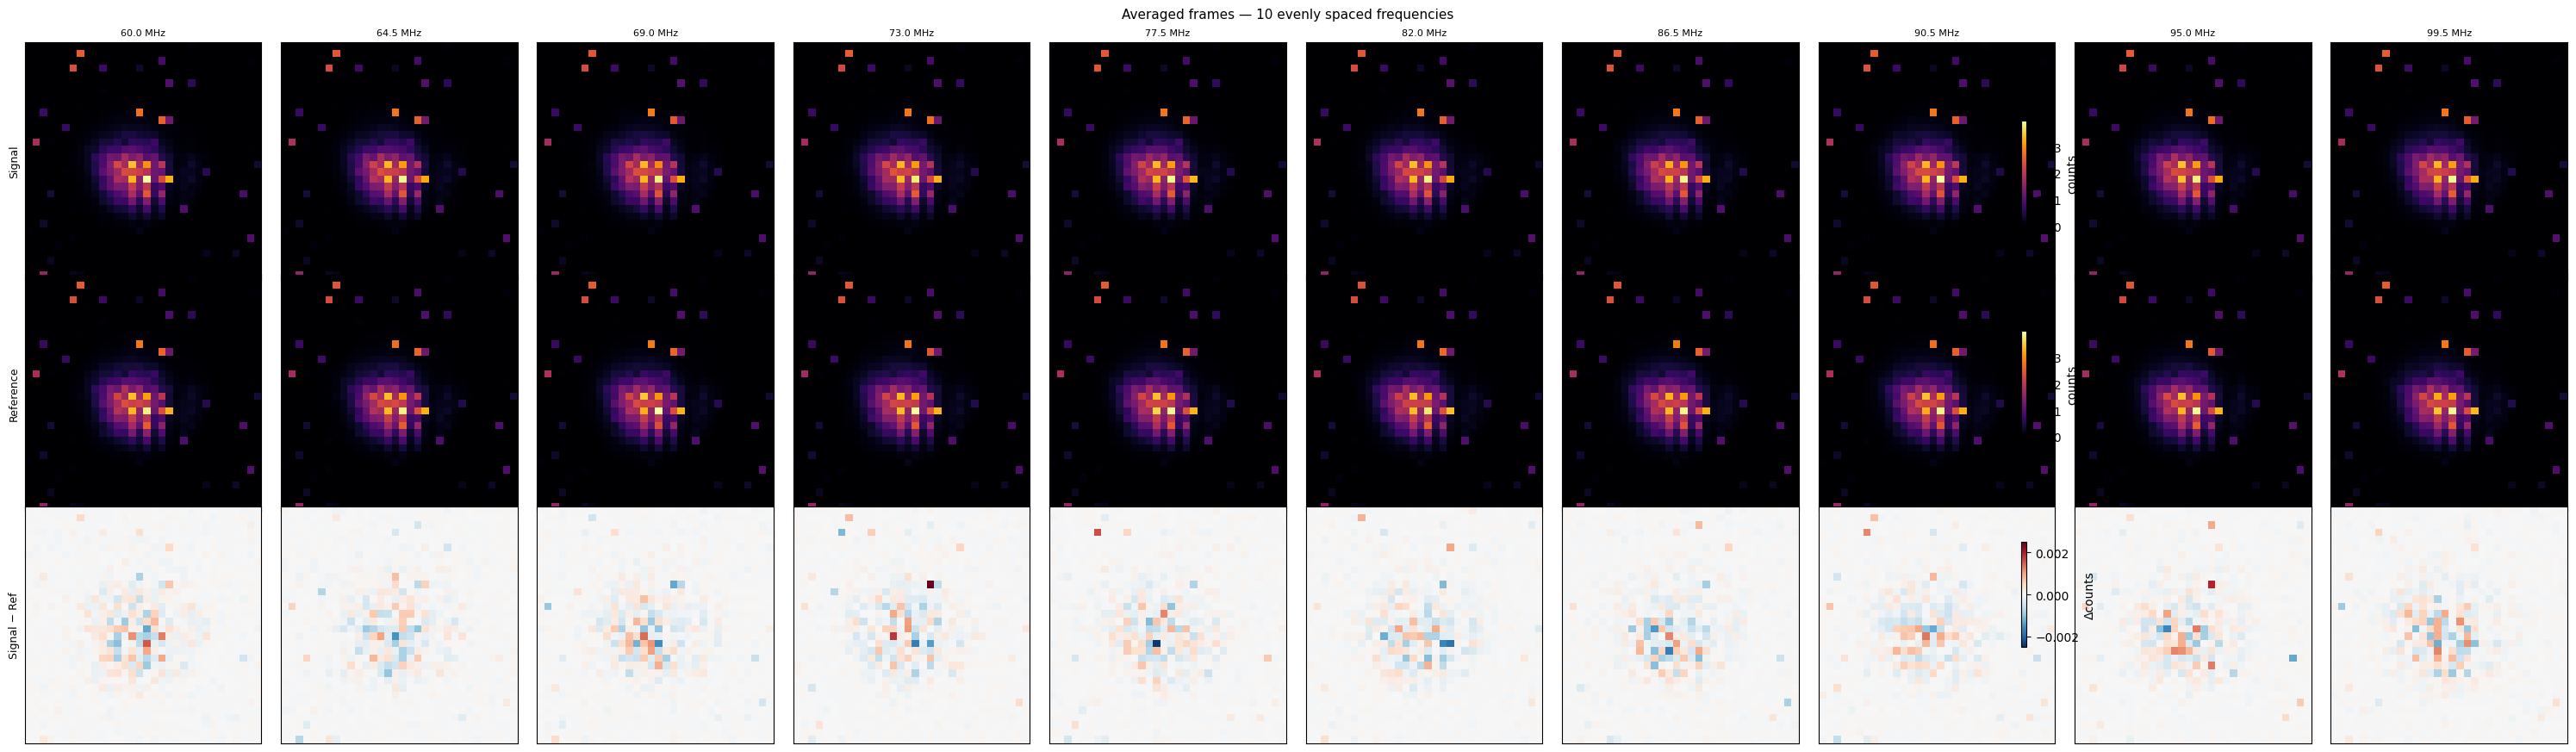

In [12]:
# Select 10 evenly spaced frequency indices across the full f_vec range
plot_idx = np.round(np.linspace(0, F - 1, 10)).astype(int)

sig_plot  = sig_avg[plot_idx]   # (10, rows, cols)
ref_plot  = ref_avg[plot_idx]
diff_plot = diff_avg[plot_idx]
f_plot    = f_vec[plot_idx]

n_show = len(plot_idx)
vmin_sr = min(sig_plot.min(), ref_plot.min())
vmax_sr = max(sig_plot.max(), ref_plot.max())
vmax_d  = np.abs(diff_plot).max() or 1

fig, axes = plt.subplots(3, n_show, figsize=(3 * n_show, 9), squeeze=False)
fig.suptitle('Averaged frames — 10 evenly spaced frequencies', fontsize=11)

for col in range(n_show):
    f_mhz = f_plot[col] / 1e6
    axes[0, col].imshow(sig_plot[col],  cmap='inferno', vmin=vmin_sr, vmax=vmax_sr, origin='lower')
    axes[1, col].imshow(ref_plot[col],  cmap='inferno', vmin=vmin_sr, vmax=vmax_sr, origin='lower')
    im2 = axes[2, col].imshow(diff_plot[col], cmap='RdBu_r', vmin=-vmax_d, vmax=vmax_d, origin='lower')
    axes[0, col].set_title(f'{f_mhz:.1f} MHz', fontsize=8)
    for row in range(3):
        axes[row, col].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

for row, label in enumerate(['Signal', 'Reference', 'Signal − Ref']):
    axes[row, 0].set_ylabel(label, fontsize=9)

im0 = axes[0, 0].images[0]
im1 = axes[1, 0].images[0]
fig.colorbar(im0, ax=axes[0, :], shrink=0.6, label='counts')
fig.colorbar(im1, ax=axes[1, :], shrink=0.6, label='counts')
fig.colorbar(im2, ax=axes[2, :], shrink=0.6, label='Δcounts')

plt.tight_layout()
plt.show()

## ODMR spectrum: total counts vs MW frequency

Sum all pixels in each averaged image to get a single number per frequency, then plot signal, reference, and normalised contrast — matching the style of `analyze_odmr.ipynb`.

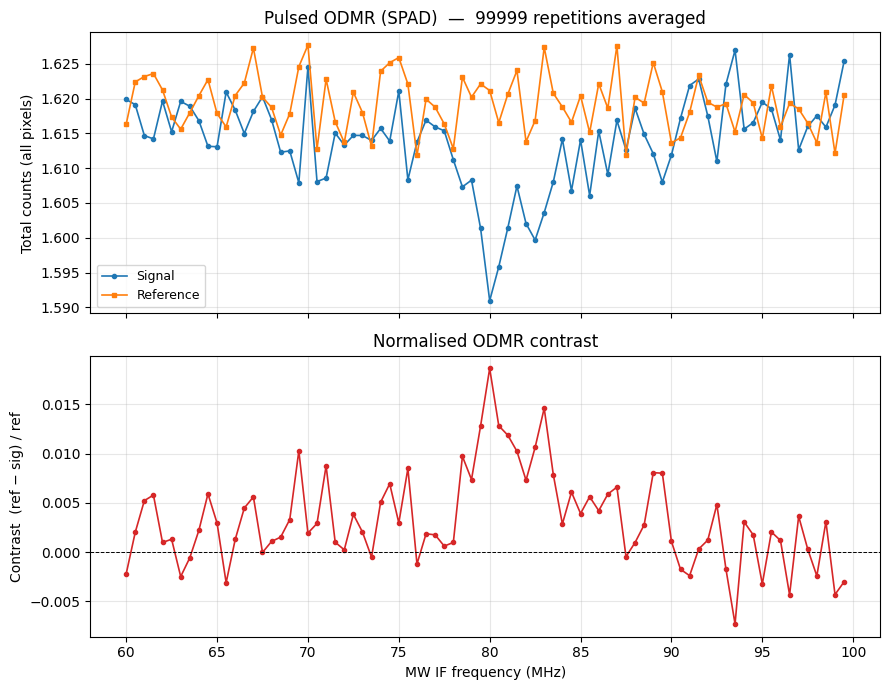


Peak contrast  : 0.0186  @ 80.00 MHz
Signal range   : 2 – 2 counts
Reference range: 2 – 2 counts


In [13]:
# Sum counts over all pixels for each frequency → 1-D ODMR spectrum
sig_counts  = sig_avg.sum(axis=(-1, -2))   # (F,)
ref_counts  = ref_avg.sum(axis=(-1, -2))   # (F,)
diff_counts = sig_counts - ref_counts       # (F,)

# Normalised contrast: (ref - sig) / ref  (positive dip = ODMR resonance)
with np.errstate(divide='ignore', invalid='ignore'):
    contrast = np.where(ref_counts != 0, (ref_counts - sig_counts) / ref_counts, 0.0)

f_mhz = f_vec / 1e6

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

# --- Top panel: raw counts ---
axes[0].plot(f_mhz, sig_counts,  'o-', ms=3, lw=1.2, label='Signal')
axes[0].plot(f_mhz, ref_counts,  's-', ms=3, lw=1.2, label='Reference')
#axes[0].plot(f_mhz, diff_counts, '^-', ms=3, lw=1.2, label='Signal − Ref', color='C2')
axes[0].set_ylabel('Total counts (all pixels)')
axes[0].set_title(f'Pulsed ODMR (SPAD)  —  {n_complete_reps} repetitions averaged')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# --- Bottom panel: normalised contrast ---
axes[1].plot(f_mhz, contrast, 'o-', ms=3, lw=1.2, color='C3')
axes[1].axhline(0, color='k', lw=0.7, ls='--')
axes[1].set_xlabel('MW IF frequency (MHz)')
axes[1].set_ylabel('Contrast  (ref − sig) / ref')
axes[1].set_title('Normalised ODMR contrast')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nPeak contrast  : {contrast.max():.4f}  @ {f_mhz[np.argmax(contrast)]:.2f} MHz")
print(f"Signal range   : {sig_counts.min():.0f} – {sig_counts.max():.0f} counts")
print(f"Reference range: {ref_counts.min():.0f} – {ref_counts.max():.0f} counts")


## Per-pixel ODMR contrast map

For each pixel, compute peak contrast = max over frequencies of `(ref − sig) / ref`. This spatial map highlights which pixels on the SPAD array are coupled to the NV spin.

In [ ]:
# Per-pixel contrast at each frequency: (ref - sig) / ref  shape: (F, rows, cols)
with np.errstate(divide='ignore', invalid='ignore'):
    contrast_map = np.where(ref_avg != 0, (ref_avg - sig_avg) / ref_avg, 0.0)

# Peak contrast map: maximum contrast across all frequencies for each pixel
peak_contrast_map = contrast_map.max(axis=0)          # (rows, cols)
peak_freq_idx_map = contrast_map.argmax(axis=0)       # index into f_vec
peak_freq_map_mhz = f_mhz[peak_freq_idx_map]          # (rows, cols)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

im0 = axes[0].imshow(sig_avg.mean(axis=0),    cmap='inferno', origin='lower')
axes[0].set_title('Signal (mean over freqs)')
fig.colorbar(im0, ax=axes[0], label='counts')

im1 = axes[1].imshow(peak_contrast_map, cmap='viridis', origin='lower',
                     vmin=0, vmax=max(peak_contrast_map.max(), 1e-6))
axes[1].set_title('Peak contrast per pixel')
fig.colorbar(im1, ax=axes[1], label='(ref−sig)/ref')

im2 = axes[2].imshow(peak_freq_map_mhz, cmap='coolwarm', origin='lower')
axes[2].set_title('Frequency of peak contrast (MHz)')
fig.colorbar(im2, ax=axes[2], label='MHz')

for ax in axes:
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

plt.suptitle('Per-pixel ODMR contrast map', fontsize=11)
plt.tight_layout()
plt.show()

print(f"Max peak contrast : {peak_contrast_map.max():.4f}  "
      f"at pixel (row={np.unravel_index(peak_contrast_map.argmax(), peak_contrast_map.shape)[0]}, "
      f"col={np.unravel_index(peak_contrast_map.argmax(), peak_contrast_map.shape)[1]})")
